In [1]:
import pandas as pd

# Load data
df = pd.read_excel("era5_combine.xlsx")

# Rename columns
df.rename(columns={
    'year': 'Date',
    'hur': 'hurs'
}, inplace=True)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Reorder columns
df = df[['Date', 'Year', 'Month', 'tas', 'pr', 'hurs']]

# Check result
df.head()

,Date,Year,Month,tas,pr,hurs
0,1950-01-01,1950,1,17.73,26.12,54.02
1,1950-02-01,1950,2,17.80,32.82,51.17
2,1950-03-01,1950,3,21.10,76.44,57.22
3,1950-04-01,1950,4,26.60,27.66,41.02
4,1950-05-01,1950,5,29.38,70.18,47.42


In [2]:
df.isnull().sum()

Date     0
Year     0
Month    0
tas      0
pr       0
hurs     0
dtype: int64

In [3]:
df.describe()

,Date,Year,Month,tas,pr,hurs
count,888,888.000000,888.000000,888.000000,888.000000,888.000000
mean,1986-12-16 04:51:53.513513,1986.500000,6.500000,23.941745,99.541712,61.865597
min,1950-01-01 00:00:00,1950.000000,1.000000,15.080000,3.570000,31.860000
25%,1968-06-23 12:00:00,1968.000000,3.750000,20.205000,23.040000,51.580000
50%,1986-12-16 12:00:00,1986.500000,6.500000,25.110000,50.050000,61.265000
75%,2005-06-08 12:00:00,2005.000000,9.250000,27.062500,170.840000,72.710000
max,2023-12-01 00:00:00,2023.000000,12.000000,30.830000,370.420000,84.350000
std,NaN,21.372047,3.453998,4.205925,98.716432,12.613196


In [4]:
df.to_csv("clean_climate_data.csv", index=False)

In [5]:
# Lag features (past values)
df['lag_1'] = df['tas'].shift(1)
df['lag_2'] = df['tas'].shift(2)
df['lag_12'] = df['tas'].shift(12)  # same month last year

In [6]:
# Rolling averages
df['rolling_mean_3'] = df['tas'].rolling(window=3).mean()
df['rolling_mean_12'] = df['tas'].rolling(window=12).mean()

In [7]:
df = df.dropna()

In [8]:
features = ['lag_1', 'lag_2', 'lag_12', 'rolling_mean_3', 'rolling_mean_12', 'pr', 'hurs', 'Month', 'Year']
target = 'tas'

X = df[features]
y = df[target]

In [9]:
train = df[df['Year'] <= 2015]
test = df[df['Year'] > 2015]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.098321516541546e-14
RMSE: 3.169979994312318e-14


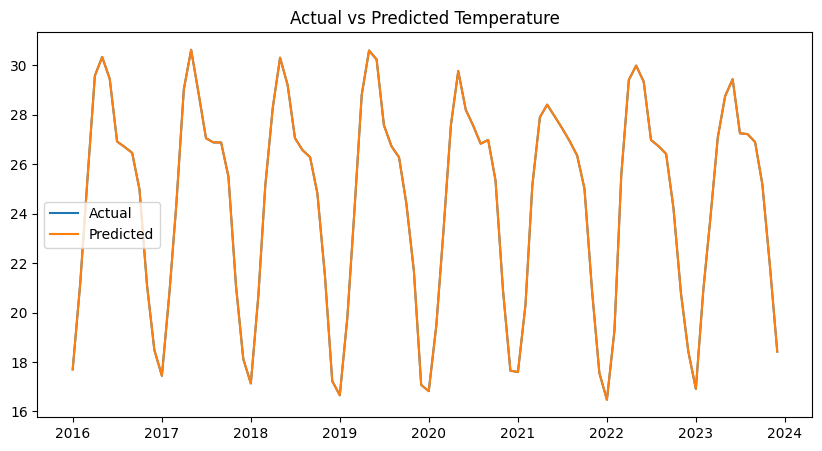

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test['Date'], y_test, label='Actual')
plt.plot(test['Date'], y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Temperature")
plt.show()

In [14]:
last_data = df.iloc[-1:].copy()

In [15]:
future_predictions = []

current = last_data.copy()

for i in range(12):  # 12 months ahead
    
    # Predict next value
    pred = model.predict(current[features])[0]
    
    future_predictions.append(pred)
    
    # Update row for next prediction
    current['lag_1'] = pred
    current['lag_2'] = current['lag_1']
    
    # shift month/year
    current['Month'] = current['Month'] + 1
    
    if current['Month'].values[0] > 12:
        current['Month'] = 1
        current['Year'] = current['Year'] + 1

In [16]:
import pandas as pd

last_date = df['Date'].iloc[-1]

future_dates = pd.date_range(start=last_date, periods=13, freq='ME')[1:]

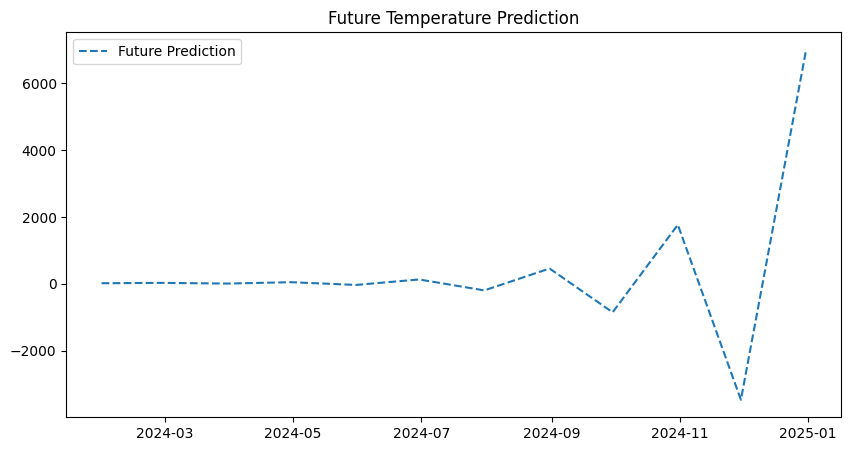

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Past data
plt.plot(df['Date'], df['tas'], label='Historical')

# Future
plt.plot(future_dates, future_predictions, label='Future Prediction', linestyle='--')

plt.legend()
plt.title("Future Temperature Prediction")
plt.show()